## Plot embeddings

In [12]:
import anndata as ad
from matplotlib import pyplot as plt
import scanpy as sc

In [8]:
# fname = '/home/jupyter/__output/brca_full/cell_type/gf-6L-30M-i2048/data.h5ad'
fname = '/home/haitham/mnt/__output_v7/exp/geneformer/V1-10M-i2048/brca_cell_type_geneformer_V1-10M-i2048_brca_cell_type/data.h5ad'

adata_v1 =ad.read_h5ad(fname)

In [3]:
# fname = '/home/jupyter/__output/brca_full/cell_type/Geneformer-V2-104M_continue/data.h5ad'
# fname = '/home/jupyter/__output/brca_full/cell_type/gf-6L-30M-i2048_continue/data.h5ad'
fname = '/home/haitham/mnt/__output_v7/exp/geneformer/V1-10M-i2048/brca_cell_type_continue_geneformer_V1-10M-i2048_continue_brca_cell_type/data.h5ad'

adata_v1_continue =ad.read_h5ad(fname)

In [4]:

# fname = '/home/jupyter/__output/brca_full/cell_type/scvi/data.h5ad'
fname = '/home/haitham/mnt/__output_v7/exp/scvi/default/brca_cell_type_scvi_brca_cell_type/data.h5ad'

adata_scvi =ad.read_h5ad(fname)

In [5]:
fname = '/home/haitham/mnt/__output_v7/exp/pca/n100/brca_cell_type_pca_n100_brca_cell_type/data.h5ad'

adata_pca =ad.read_h5ad(fname)

/home/haitham/scFM_eval/.pixi/envs/geneformer/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


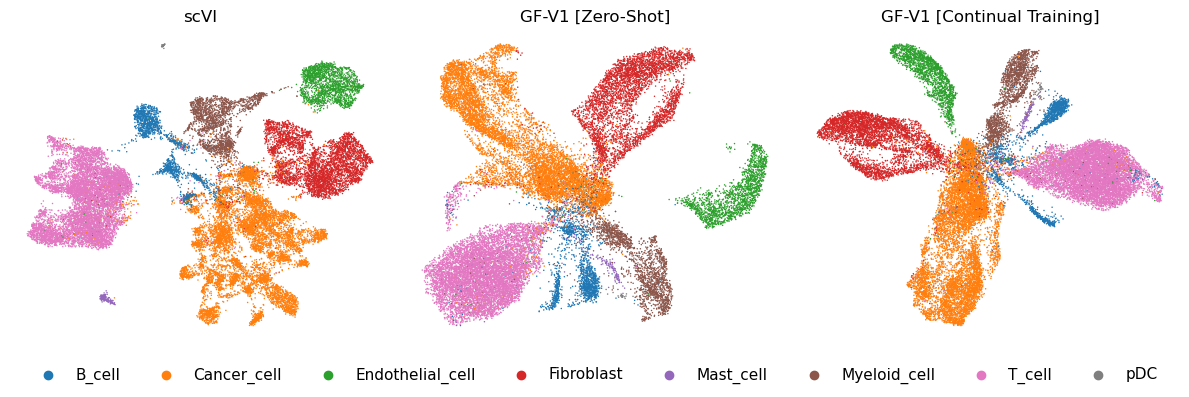

In [15]:
# Create the side-by-side plot
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
datasets= [ adata_scvi, adata_v1, adata_v1_continue]
titles = ['scVI', 'GF-V1 [Zero-Shot]', 'GF-V1 [Continual Training]']
use_rep = ['X_scVI', 'X_geneformer', 'X_geneformer'] 
for i, (ax, ad, title) in enumerate(zip(axes, datasets, titles)):
    sc.pp.neighbors(ad,n_neighbors=25, use_rep=use_rep[i])
    sc.tl.umap(ad)
    sc.pl.umap(ad, color='label', ax=ax, show=False, title=title, frameon=False)

# Hide individual legends from scanpy plots
for ax in axes:
    ax.get_legend().remove()  # Remove default scanpy legend
    ax.spines[:].set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])

# Create a single, shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=len(set(labels)), frameon=False, fontsize=11)

# Final layout adjustments
plt.tight_layout(rect=[0, 0.1, 1, 1])  # Leaves space at bottom for the legend
# plt.subplots_adjust(right=0.9)
plt.savefig('./plots/umap.png', dpi=100)
plt.show()